# 01 · Historical Elections: Eastern Cape LGE 2000–2021

**Eastern Cape Municipal Electoral Dynamics** · University of Fort Hare · DIRISA Student Datathon Challenge 2026
Notebook 1 of 6. Run the notebooks in order (01 → 06); each one writes the processed files the next one reads.

**What this notebook does.** It rebuilds two decades of municipal election results from the raw IEC files, puts every election onto one consistent map of 33 municipalities, and checks the result against the IEC's own official turnout reports.

| | |
|---|---|
| **Inputs** | `data/raw/detailed/` (IEC detailed LGE results 2000–2021), `data/raw/turnout/` (IEC turnout reports), `data/raw/geo/za-local.topojson` (MDB 2011 boundaries) |
| **Outputs** | `data/processed/elections/phase1/*.csv`, `data/external/geo/ec_municipalities_33.geojson`, figures in `reports/figures/phase1/` |
| **Code** | `src/data/elections.py`, `src/data/geography.py`, `src/config.py` |

**At a glance**
- 164 municipality-election observations: 32 municipalities in 2000 and 33 in 2006, 2011, 2016 and 2021.
- Registered voters reconstructed from raw files match the IEC's official 2016 and 2021 municipal reports exactly; turnout agrees to within about 0.3 percentage points on average.
- The 2000 and 2006 provincial totals reconcile exactly once the units outside the analytical geography are accounted for.

## Why this step matters

The IEC publishes rich election data, but each election uses a slightly different file layout, and municipal boundaries changed between elections (most notably in 2016, when several municipalities merged). Comparing municipalities across time is only meaningful if every election is first expressed on the **same geography** and measured the **same way**. This notebook does that once, so every later step uses identical numbers.

In [1]:
# Setup: locate the repository root so this notebook runs from any working folder,
# then import the shared project code in src/ (the single source of truth for logic).
import sys, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as C
from src.visualization.style import apply_style, subtitle, save, choropleth, map_colorbar, source_note, SEQ_CMAP, DIV_CMAP

apply_style()
C.ensure_dirs()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)
print("Repository root:", ROOT.name)

Repository root: Dirisa_TeamQualification


## 1. Load the raw IEC files

There are two schema generations: 2000/2006 (`Voting District`, `Party`, `Valid Votes Cast`, ...) and 2011/2016/2021 (`VotingDistrict`, `PartyName`, `TotalValidVotes`, ...). The 2011 file is UTF-16 encoded. `read_election_file` handles both.

In [2]:
from src.data import elections as E

raw = {year: E.read_election_file(year) for year in C.ELECTION_YEARS}

schema = pd.DataFrame([
    {"Year": y, "Rows": len(df), "Columns": df.shape[1],
     "Ballot types": ", ".join(sorted(df[[c for c in df.columns if c.replace(' ', '') == 'BallotType'][0]].astype(str).str.strip().unique())),
     "Example columns": ", ".join(df.columns[:6])}
    for y, df in raw.items()
])
display(schema)

# Malformed-row check: in 2006 a few rows have a party name containing a comma,
# which shifts their columns. Confirm none are in the Eastern Cape.
bt = raw[2006]["Ballot Type"].astype(str).str.strip()
malformed = raw[2006][~bt.isin(["PR", "WARD", "DC 40%", "DMA DC 60%"])]
print(f"2006 malformed rows: {len(malformed)} | provinces affected: {malformed['Province'].unique().tolist()}")
assert not malformed["Province"].str.contains("Eastern", case=False).any()

,Year,Rows,Columns,Ballot types,Example columns
0,2000,199566,12,"DC 40%, DMA DC 60%, PR, WARD","Electoral Event, Province, Municipality, Ward,..."
1,2006,374695,14,"DC 40%, DMA DC 60%, PR, PROTEA CITY AND GREENS...","Electoral Event, Province, Municipality, Ward,..."
2,2011,76488,11,"DC 40%, PR, Ward","Province, Municipality, Ward, VotingDistrict, ..."
3,2016,102919,11,"DC 40%, PR, Ward","Province, Municipality, Ward, VotingDistrict, ..."
4,2021,156083,11,"DC 40%, PR, Ward","Province, Municipality, Ward, VotingDistrict, ..."


2006 malformed rows: 6 | provinces affected: ['Gauteng']


The 2006 file contains six malformed rows (a party name with a comma shifted their columns); all are in Gauteng, so they do not affect this analysis.

Each file holds one row per **party × voting district × ballot**. We keep only the **PR (proportional representation) ballot**: it is the one ballot every voter in every municipality receives, so it gives a consistent measure of party support across all five elections.

## 2. Harmonise municipalities to one geography

The analytical geography is the 33 municipalities that exist today. Older units are mapped onto them with an explicit crosswalk, never by name matching.

In [3]:
crosswalk = pd.DataFrame(
    [{"HistoricalCode": k, "TargetCode": v, "TargetMunicipality": C.muni_name(v)} for k, v in C.CODE_MAP.items()]
).sort_values(["TargetCode", "HistoricalCode"]).reset_index(drop=True)
display(crosswalk)

,HistoricalCode,TargetCode,TargetMunicipality
0,EC125,BUF,Buffalo City
1,EC103,EC101,Dr Beyers Naude
2,EC107,EC101,Dr Beyers Naude
3,EC127,EC129,Raymond Mhlaba
4,EC128,EC129,Raymond Mhlaba
5,EC132,EC139,Enoch Mgijima
6,EC133,EC139,Enoch Mgijima
7,EC134,EC139,Enoch Mgijima
8,EC143,EC145,Walter Sisulu
9,EC144,EC145,Walter Sisulu


Two kinds of unit are **excluded on purpose**:

- **EC05b1 Umzimkulu** was in the Eastern Cape in 2000 but moved to KwaZulu-Natal in 2006, so it has no present-day Eastern Cape equivalent.
- **District Management Areas (ECDMA…)** elected only district councils, not local councils.

Matatiele only joined the Eastern Cape in 2006, which is why 2000 has 32 municipalities rather than 33.

## 3. Aggregate to municipality level

Within each voting district the IEC repeats registered voters and spoilt ballots on every party row, so these are **counted once per voting district** and then summed. Party votes are summed over all rows. Then:

$$\text{Turnout}_{m,t} = 100 \times \frac{\text{Valid votes} + \text{Spoilt votes}}{\text{Registered voters}}, \qquad \text{Share}_{p,m,t} = 100 \times \frac{\text{Votes}_{p}}{\text{Valid votes}}$$

$$\text{ENP}_{m,t} = \frac{1}{\sum_i p_i^2}\;(\text{Laakso–Taagepera}), \qquad \text{Margin}_{m,t} = \text{Share}_{1st} - \text{Share}_{2nd}$$

ENP and margin are computed from the **full** party distribution, before small parties are grouped into OTHER.

In [4]:
tables = E.build_election_tables(raw)
panel, party_long, party_wide = tables["panel"], tables["party_long"], tables["party_wide"]

print("Municipality-election observations:", len(panel))
display(panel.groupby("Year").agg(Municipalities=("MuniCode", "nunique"),
                                  RegisteredVoters=("RegisteredVoters", "sum"),
                                  VotesCast=("VotesCast", "sum"),
                                  VotingDistricts=("VotingDistricts", "sum")))
print("Raw units outside the analytical geography:")
display(tables["dropped"])

Municipality-election observations: 164


,Municipalities,RegisteredVoters,VotesCast,VotingDistricts
Year,,,,
2000,32,2494398,1400730,2992
2006,33,2905636,1636860,4357
2011,33,3111535,1800229,4560
2016,33,3337532,1874838,4699
2021,33,3253307,1508103,4809


Raw units outside the analytical geography:


,Municipality,HistoricalCode,Year
0,EC05b1 - Umzimkulu [Umzimkulu],EC05B1,2000


## 4. Independent validation against the IEC's official turnout reports

A reconstruction is only trustworthy if it agrees with an independent source. The IEC's *Voter Turnout Reports* (in `data/raw/turnout/`) are produced by the IEC itself and were not used to build the panel.

Note the definitions differ slightly: the IEC divides the **larger of ward or PR votes cast** by **registered voters plus MEC7 special votes**, whereas we use PR votes cast over registered voters. Small turnout differences are therefore expected; registered voters should match exactly.

,Year,Municipalities,MaxRegisteredVoterDifference,MeanAbsTurnoutDiff_pts,MaxAbsTurnoutDiff_pts,Correlation
0,2016,33,0,0.32,2.31,0.99
1,2021,33,0,0.31,1.26,1.00


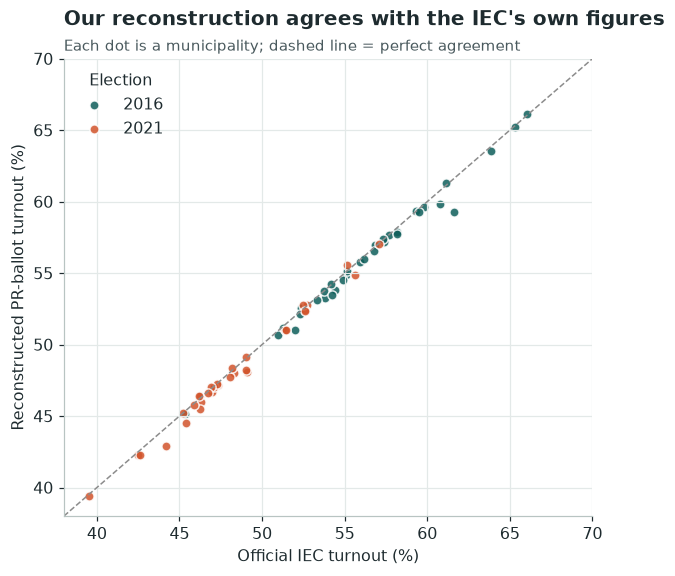

In [5]:
rows = []
for y in [2016, 2021]:
    off = E.read_iec_turnout_report(C.IEC_TURNOUT_REPORTS[y]).dropna(subset=["MuniCode"])
    m = panel[panel["Year"] == y].merge(off, on="MuniCode", suffixes=("", "_IEC"))
    m["Year"] = y
    rows.append(m)
muni_check = pd.concat(rows, ignore_index=True)
muni_check["TurnoutDiff_pts"] = muni_check["Turnout_%"] - muni_check["Turnout_%_IEC"]

val_muni = muni_check.groupby("Year").agg(
    Municipalities=("MuniCode", "count"),
    MaxRegisteredVoterDifference=("RegisteredVoters", lambda s: int((s - muni_check.loc[s.index, "RegisteredVoters_IEC"]).abs().max())),
    MeanAbsTurnoutDiff_pts=("TurnoutDiff_pts", lambda s: s.abs().mean()),
    MaxAbsTurnoutDiff_pts=("TurnoutDiff_pts", lambda s: s.abs().max()),
    Correlation=("Turnout_%", lambda s: np.corrcoef(s, muni_check.loc[s.index, "Turnout_%_IEC"])[0, 1]),
).reset_index()
display(val_muni)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
for y, col in [(2016, C.TEAL), (2021, C.ALOE)]:
    d = muni_check[muni_check["Year"] == y]
    ax.scatter(d["Turnout_%_IEC"], d["Turnout_%"], s=36, color=col, alpha=.85, label=str(y), edgecolor="white")
lims = [38, 70]
ax.plot(lims, lims, color=C.GREY, lw=1, ls="--")
ax.set(xlim=lims, ylim=lims, xlabel="Official IEC turnout (%)", ylabel="Reconstructed PR-ballot turnout (%)")
ax.set_title("Our reconstruction agrees with the IEC's own figures", pad=22)
subtitle(ax, "Each dot is a municipality; dashed line = perfect agreement")
ax.legend(title="Election")
save(fig, "iec_official_validation", "phase1"); plt.show()

**Reading the chart.** Every municipality sits on or very close to the line of perfect agreement, and registered voters match the IEC exactly. The remaining small gaps come from the definitional difference above (special votes and ward-vs-PR ballots), not from processing errors.

The older reports only give province totals, so we reconcile those instead:

In [6]:
prov_rows = []
for y in C.ELECTION_YEARS:
    off = E.read_iec_turnout_report(C.IEC_TURNOUT_REPORTS[y])
    off_ec = off[off["Unit"].str.contains("Eastern", case=False)]
    if off_ec.empty:  # 2016/2021 reports are municipal: sum them
        off_ec = off.dropna(subset=["MuniCode"])
        iec_reg = off_ec["RegisteredVoters"].sum()
    else:
        iec_reg = off_ec["RegisteredVoters"].iloc[0]
    ours = panel.loc[panel["Year"] == y, "RegisteredVoters"].sum()
    prov_rows.append({"Year": y, "IEC registered (EC)": int(iec_reg), "Panel registered": int(ours),
                      "Difference": int(iec_reg - ours)})
reconcile = pd.DataFrame(prov_rows)
reconcile["Explanation"] = reconcile["Difference"].map(lambda d: "Exact match" if d == 0 else "")
reconcile.loc[reconcile["Year"] == 2000, "Explanation"] = "Umzimkulu (EC05b1) excluded: moved to KwaZulu-Natal in 2006"
reconcile.loc[reconcile["Year"] == 2006, "Explanation"] = "District Management Area voters (district ballot only) excluded"
display(reconcile)

# Exact check for the 2000 explanation: the gap must equal Umzimkulu's registered voters.
x = raw[2000]
x = x[(x["Province"].str.strip().str.lower() == "eastern cape") & (x["Ballot Type"].str.strip().str.upper() == "PR")]
umz = x[x["Municipality"].str.startswith("EC05b1")].drop_duplicates("Voting District")
umzimkulu_registered = int(E.numeric(umz["Registered Voters"]).sum())
print("Umzimkulu registered voters, 2000:", f"{umzimkulu_registered:,}")
assert umzimkulu_registered == reconcile.loc[reconcile["Year"] == 2000, "Difference"].iloc[0]

,Year,IEC registered (EC),Panel registered,Difference,Explanation
0,2000,2550072,2494398,55674,Umzimkulu (EC05b1) excluded: moved to KwaZulu-...
1,2006,2908106,2905636,2470,District Management Area voters (district ball...
2,2011,3111535,3111535,0,Exact match
3,2016,3337532,3337532,0,Exact match
4,2021,3253307,3253307,0,Exact match


Umzimkulu registered voters, 2000: 55,674


Every election reconciles: 2011, 2016 and 2021 match exactly, the 2000 gap equals Umzimkulu's 55,674 voters to the person, and the small 2006 gap is the District Management Area electorate.

## 5. Reproducibility check against the earlier prototype

The team's earlier prototype produced `clean_res*.csv` and `clean_competition_all.csv` (now kept in `data/processed/legacy_prototype/`). They are **not** inputs here; we only confirm the rebuilt pipeline reproduces them.

In [7]:
legacy_rows = []
for y in C.ELECTION_YEARS:
    old = pd.read_csv(C.DIRS["legacy"] / f"clean_res{str(y)[-2:]}.csv")
    chk = panel[panel["Year"] == y].merge(old, on="MuniCode", suffixes=("", "_old"))
    legacy_rows.append({"Year": y, "Matched": len(chk),
                        "MaxRegisteredDiff": float((chk["RegisteredVoters"] - chk["RegisteredVoters_old"]).abs().max()),
                        "MaxValidVotesDiff": float((chk["ValidVotes"] - chk["ValidVotes_old"]).abs().max()),
                        "MaxTurnoutDiff_pts": float((chk["Turnout_%"] - chk["Turnout_%_old"]).abs().max())})
legacy_val = pd.DataFrame(legacy_rows)
old_comp = pd.read_csv(C.DIRS["legacy"] / "clean_competition_all.csv")
cc = tables["competition"].merge(old_comp, on=["MuniCode", "Year"], suffixes=("", "_old"))
legacy_val["MaxENPDiff"] = float((cc["ENP"] - cc["ENP_old"]).abs().max())
legacy_val["MaxMarginDiff_pts"] = float((cc["Margin_pts"] - cc["Margin_pts_old"]).abs().max())
display(legacy_val)

,Year,Matched,MaxRegisteredDiff,MaxValidVotesDiff,MaxTurnoutDiff_pts,MaxENPDiff,MaxMarginDiff_pts
0,2000,32,0.0,0.0,1.42e-14,1.33e-15,1.42e-14
1,2006,33,0.0,0.0,7.11e-15,1.33e-15,1.42e-14
2,2011,33,0.0,0.0,1.42e-14,1.33e-15,1.42e-14
3,2016,33,0.0,0.0,1.42e-14,1.33e-15,1.42e-14
4,2021,33,0.0,0.0,1.42e-14,1.33e-15,1.42e-14


All differences are zero to floating-point precision.

## 6. A first look: registration, participation and party competition

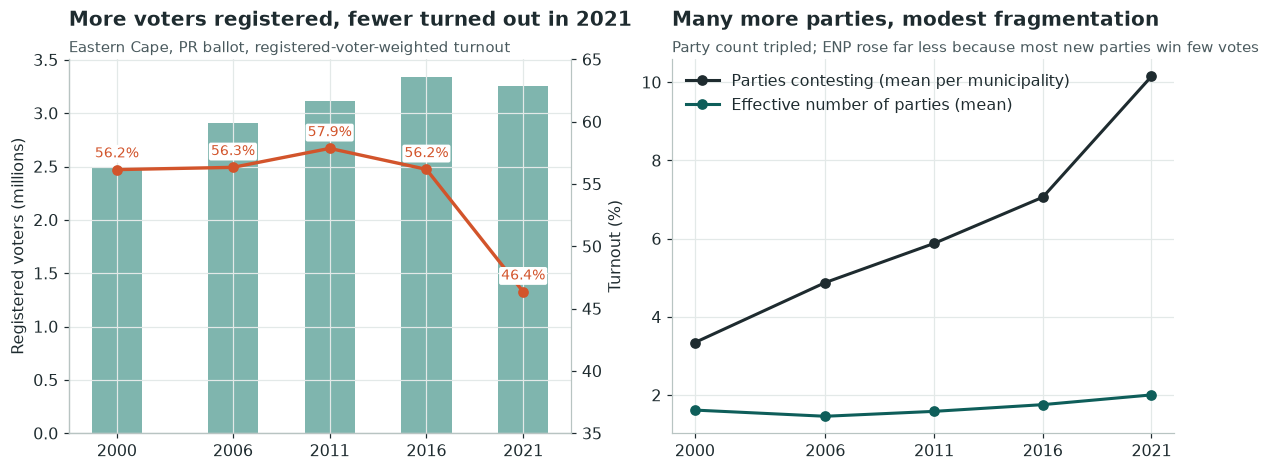

,Year,Registered,Cast,Parties,ENP,Turnout
0,2000,2494398,1400730,3.34,1.62,56.16
1,2006,2905636,1636860,4.88,1.46,56.33
2,2011,3111535,1800229,5.88,1.58,57.86
3,2016,3337532,1874838,7.06,1.76,56.17
4,2021,3253307,1508103,10.15,2.00,46.36


In [8]:
yr = panel.groupby("Year").agg(Registered=("RegisteredVoters", "sum"), Cast=("VotesCast", "sum"),
                              Parties=("NumberOfParties", "mean"), ENP=("ENP", "mean")).reset_index()
yr["Turnout"] = 100 * yr["Cast"] / yr["Registered"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
ax.bar(yr["Year"], yr["Registered"] / 1e6, width=2.6, color=C.TEAL_LIGHT, label="Registered voters (m)")
ax.set_ylabel("Registered voters (millions)")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(yr["Year"], yr["Turnout"], color=C.ALOE, marker="o", lw=2.2, label="Turnout (%)")
for x_, y_ in zip(yr["Year"], yr["Turnout"]):
    ax2.annotate(f"{y_:.1f}%", (x_, y_), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color=C.ALOE,
                 bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"))
ax2.set_ylim(35, 65); ax2.set_ylabel("Turnout (%)"); ax2.spines["right"].set_visible(True)
ax.set_xticks(yr["Year"]); ax.set_title("More voters registered, fewer turned out in 2021", pad=22)
subtitle(ax, "Eastern Cape, PR ballot, registered-voter-weighted turnout")

ax = axes[1]
ax.plot(yr["Year"], yr["Parties"], marker="o", color=C.INK, lw=2, label="Parties contesting (mean per municipality)")
ax.plot(yr["Year"], yr["ENP"], marker="o", color=C.TEAL, lw=2, label="Effective number of parties (mean)")
ax.set_xticks(yr["Year"]); ax.legend(loc="upper left")
ax.set_title("Many more parties, modest fragmentation", pad=22)
subtitle(ax, "Party count tripled; ENP rose far less because most new parties win few votes")
fig.tight_layout(); save(fig, "registration_turnout_competition", "phase1"); plt.show()
display(yr.round(2))

**What this shows.** Registration grew steadily to 2016 and dipped slightly in 2021, but the bigger change is turnout: it held at 56–58% for four elections and then fell by about 10 points in 2021. Over the same period the average number of parties on a municipal ballot rose from about 3 to about 10, while the effective number of parties rose much less, because most new entrants won small shares. Notebook 3 shows why this coincidence matters for the analysis.

## 7. The 33-municipality map

To draw maps on exactly the same geography as the data, we take the Municipal Demarcation Board's 2011 boundaries (39 Eastern Cape units) and dissolve them with **the same crosswalk** used above. Four present-day municipalities are mergers: Dr Beyers Naude (3 units), Raymond Mhlaba (2), Enoch Mgijima (3) and Walter Sisulu (2).

Map units: 33 | identical to analytical codes: True


,MuniCode,SourceUnits
0,EC101,"EC101,EC103,EC107"
1,EC129,"EC127,EC128"
2,EC139,"EC132,EC133,EC134"
3,EC145,"EC143,EC144"


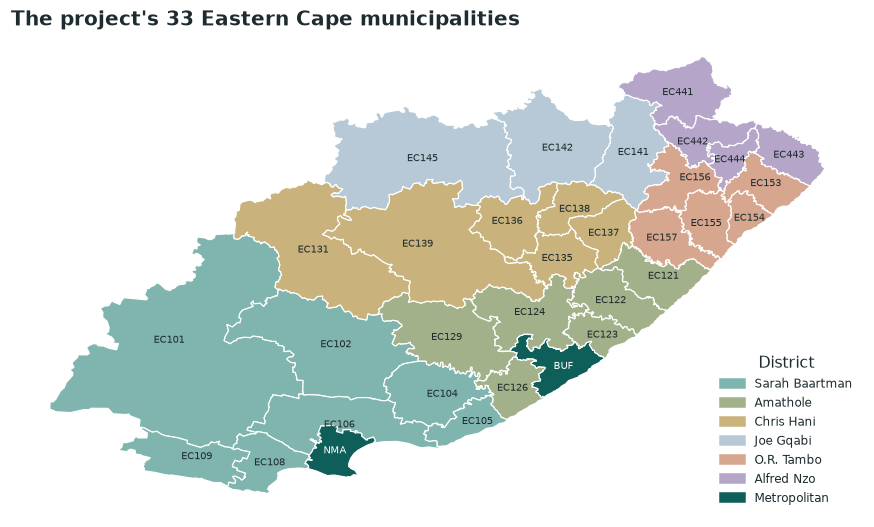

In [9]:
from src.data.geography import build_geojson
geo = build_geojson()
print("Map units:", len(geo["features"]), "| identical to analytical codes:", {f["id"] for f in geo["features"]} == C.TARGET_CODES)
display(pd.DataFrame([f["properties"] for f in geo["features"] if "," in f["properties"]["SourceUnits"]]))

district_colors = {"Sarah Baartman": "#7FB5AE", "Amathole": "#A3B18A", "Chris Hani": "#C9B27C",
                   "Joe Gqabi": "#B7C9D6", "O.R. Tambo": "#D7A68F", "Alfred Nzo": "#B5A6C9"}
values = {}
fig, ax = plt.subplots(figsize=(10, 6))
from shapely.geometry import shape
for f in geo["features"]:
    g = shape(f["geometry"]); d = C.DISTRICTS[f["id"]]
    col = C.TEAL if "metro" in d else district_colors[d]
    for poly in ([g] if g.geom_type == "Polygon" else g.geoms):
        xs, ys = poly.exterior.xy; ax.fill(xs, ys, color=col, ec="white", lw=.8)
    c = g.representative_point()
    ax.annotate(f["id"], (c.x, c.y), fontsize=6.5, ha="center", va="center", color="white" if "metro" in d else C.INK)
ax.set_aspect("equal"); ax.axis("off")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in district_colors.values()] + [plt.Rectangle((0, 0), 1, 1, color=C.TEAL)]
ax.legend(handles, list(district_colors) + ["Metropolitan"], loc="lower right", fontsize=8, title="District")
ax.set_title("The project's 33 Eastern Cape municipalities")
save(fig, "reference_map", "phase1"); plt.show()

## 8. Quality-control gates

The notebook stops with an error if any of these fail.

In [10]:
share_sums = party_long.groupby(["Year", "MuniCode"])["VoteShare_%"].sum()
qc = pd.DataFrame([
    ("Observations", len(panel), 164),
    ("Duplicate municipality-year rows", int(panel.duplicated(["MuniCode", "Year"]).sum()), 0),
    ("Turnout outside 0-100", int((~panel["Turnout_%"].between(0, 100)).sum()), 0),
    ("ENP below 1", int((panel["ENP"] < 1).sum()), 0),
    ("Margin outside 0-100", int((~panel["Margin_pts"].between(0, 100)).sum()), 0),
    ("Party-share groups not summing to 100", int((~np.isclose(share_sums, 100)).sum()), 0),
    ("Selected-party table rows not summing to 100", int((~np.isclose(party_wide[C.PARTIES].sum(axis=1), 100)).sum()), 0),
    ("2016/2021 registered voters differing from IEC", int(val_muni["MaxRegisteredVoterDifference"].max()), 0),
    ("Map units not equal to analytical codes", int({f["id"] for f in geo["features"]} != C.TARGET_CODES), 0),
], columns=["Check", "Actual", "Expected"])
qc["Pass"] = qc["Actual"] == qc["Expected"]
display(qc)
assert qc["Pass"].all(), "Phase 1 quality-control gate failed"
print("PASS: all Phase 1 checks")

,Check,Actual,Expected,Pass
0,Observations,164,164,True
1,Duplicate municipality-year rows,0,0,True
2,Turnout outside 0-100,0,0,True
3,ENP below 1,0,0,True
4,Margin outside 0-100,0,0,True
5,Party-share groups not summing to 100,0,0,True
6,Selected-party table rows not summing to 100,0,0,True
7,2016/2021 registered voters differing from IEC,0,0,True
8,Map units not equal to analytical codes,0,0,True


PASS: all Phase 1 checks


## 9. Save outputs

In [11]:
out = C.DIRS["phase1"]
iec_val = muni_check[["Year", "MuniCode", "RegisteredVoters", "RegisteredVoters_IEC", "Turnout_%", "Turnout_%_IEC", "TurnoutDiff_pts"]]
files = {
    "municipality_election_panel_2000_2021.csv": panel,
    "party_shares_long_2000_2021.csv": party_long,
    "party_shares_selected_wide_2000_2021.csv": party_wide,
    "competition_metrics_2000_2021.csv": tables["competition"],
    "municipality_crosswalk.csv": crosswalk,
    "excluded_units.csv": tables["dropped"],
    "validation_iec_official_municipal.csv": iec_val,
    "validation_iec_official_province.csv": reconcile,
    "validation_legacy_prototype.csv": legacy_val,
    "phase1_quality_control.csv": qc,
}
for name, df in files.items():
    df.to_csv(out / name, index=False)
    print(f"Saved {name:48s} {len(df):5d} rows")

Saved municipality_election_panel_2000_2021.csv          164 rows
Saved party_shares_long_2000_2021.csv                   1030 rows
Saved party_shares_selected_wide_2000_2021.csv           164 rows
Saved competition_metrics_2000_2021.csv                  164 rows
Saved municipality_crosswalk.csv                          14 rows
Saved excluded_units.csv                                   1 rows
Saved validation_iec_official_municipal.csv               66 rows
Saved validation_iec_official_province.csv                 5 rows
Saved validation_legacy_prototype.csv                      5 rows
Saved phase1_quality_control.csv                           9 rows


## Summary

- The raw IEC files for five elections now form **one consistent panel of 164 municipality-elections** on the present-day 33-municipality geography.
- The reconstruction is **independently validated**: registered voters equal the IEC's official figures, turnout agrees to within a few tenths of a point, and the older province totals reconcile exactly.
- The same crosswalk produces the **map geography**, so maps and numbers can never disagree.

**Limitation.** Harmonisation makes municipalities comparable over time, but a merged municipality in 2006 is a sum of its predecessor areas, not an identical place. Small non-merger boundary realignments in 2016 are not represented in the map.

**Next:** Notebook 02 prepares the Census context and decides which demographic values may be used for description and which for prediction.

## References

Citations were compiled by the team; verify page/URL details before final submission.

- Electoral Commission of South Africa (IEC). Municipal (Local Government) Election results, detailed downloads 2000, 2006, 2011, 2016, 2021. https://results.elections.org.za/home/downloads/me-results
- IEC. Voter Turnout Reports, LGE 2000-2021 (province and municipality level). https://results.elections.org.za
- Municipal Demarcation Board 2011 local municipal boundaries, via github.com/datawizzards/zadmaps (geojson/za-local.topojson).
- Laakso, M. & Taagepera, R. (1979). 'Effective' number of parties: a measure with application to West Europe. Comparative Political Studies, 12(1), 3-27.
- The pandas development team. pandas (software). https://pandas.pydata.org

In [12]:
# Software used in this notebook (versions recorded for reproducibility)
import platform
from importlib.metadata import version, PackageNotFoundError
rows = [("python", platform.python_version())]
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'statsmodels', 'shapely', 'xlrd', 'nbformat']:
    try:
        rows.append((pkg, version(pkg)))
    except PackageNotFoundError:
        rows.append((pkg, "not installed"))
display(pd.DataFrame(rows, columns=["Package", "Version"]))

,Package,Version
0,python,3.13.15
1,pandas,3.0.6
2,numpy,2.5.3
3,matplotlib,3.11.2
4,scikit-learn,1.9.1
5,statsmodels,0.15.0
6,shapely,2.1.2
7,xlrd,2.0.2
8,nbformat,5.11.1
